In [36]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
#configuring the visualization environment
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

In [38]:
#load origìnal data
excel_path = "C:/Users/danie/Projects (all)/ALL PROJECT/Project kaggle/Healthcare-Analytics-Kaggle/Data/raw/healthcare_dataset.csv"
df = pd.read_csv(excel_path)

In [39]:
print(df["Name"].count())

55500


In [50]:
print("Total rows:", len(df))
print("Unique patients:", df["name"].nunique())

Total rows: 54966
Unique patients: 40235


In [49]:
print("Total records:", len(df))
print("Unique patient names:", df["name"].nunique())
print("Duplicate patient names:", df["name"].duplicated().sum())

Total records: 54966
Unique patient names: 40235
Duplicate patient names: 14731


In [ ]:
duplicates = df[df["name"].duplicated(keep=False)].sort_values("name")

print(duplicates[["name"]])

                   name
54112      Aaron Archer
3040       Aaron Archer
10399       Aaron Baker
39711       Aaron Baker
13018    Aaron Bradshaw
...                 ...
27622  Zachary Thompson
22540  Zachary Williams
51915  Zachary Williams
54593    Zachary Wright
44193    Zachary Wright

[24121 rows x 1 columns]


In [ ]:
print("Python rows:", len(df))
print("Python unique names:", df["name"].nunique())

Python rows: 54966
Python unique names: 40235


In [ ]:

print(df["billing_amount"].head(10).to_string())
print(df["billing_amount"].dtype)
print(df["billing_amount"].describe())

0    18856.281306
1    33643.327287
2    27955.096079
3    37909.782410
4    14238.317814
5    48145.110951
6    19580.872345
7    45820.462722
8    50119.222792
9    19784.631062
float64
count    55500.000000
mean     25539.316097
std      14211.454431
min      -2008.492140
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: billing_amount, dtype: float64


# -------------------------
# DATA CLEANING
# -------------------------

In [42]:
# Remove duplicates
df = df.drop_duplicates()

In [43]:
# Clean column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

In [44]:
# Clean text
text_cols = df.select_dtypes(include='str').columns
# Convert names to proper case
df["name"] = df["name"].str.title()

In [45]:
# Convert dates correctly
df["date_of_admission"] = pd.to_datetime(df["date_of_admission"], errors="coerce")
df["discharge_date"] = pd.to_datetime(df["discharge_date"], errors="coerce")

In [46]:
#check the outcome of the correction
print(df[["date_of_admission", "discharge_date"]].dtypes)

date_of_admission    datetime64[us]
discharge_date       datetime64[us]
dtype: object


In [47]:
#Display the first row:
print(df.iloc[0])

name                        Bobby Jackson
age                                    30
gender                               Male
blood_type                             B-
medical_condition                  Cancer
date_of_admission     2024-01-31 00:00:00
doctor                      Matthew Smith
hospital                  Sons and Miller
insurance_provider             Blue Cross
billing_amount               18856.281306
room_number                           328
admission_type                     Urgent
discharge_date        2024-02-02 00:00:00
medication                    Paracetamol
test_results                       Normal
Name: 0, dtype: object


In [48]:
#add US dollars $ sign
df["billing_amount"] = (df["billing_amount"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False))
#convert the column data type to numeric data type
df["billing_amount"] = pd.to_numeric(df["billing_amount"], errors="coerce")
print(df["billing_amount"].head())



0    18856.281306
1    33643.327287
2    27955.096079
3    37909.782410
4    14238.317814
Name: billing_amount, dtype: float64


# -------------------------
# DATA TRANSFORMATION
# -------------------------

In [51]:
# Create a new column Length of Stay
df["length_of_stay"] = (
    df["discharge_date"] -
    df["date_of_admission"]
).dt.days

df["length_of_stay"].describe()
df[[
    "date_of_admission",
    "discharge_date",
    "length_of_stay"
]].head()

# Create additional date variables
df["admission_year"] = (
    df["date_of_admission"].dt.year
)

df["admission_month"] = (
    df["date_of_admission"].dt.month
)

df["admission_month_name"] = (
    df["date_of_admission"].dt.month_name()
)

df["admission_quarter"] = (
    df["date_of_admission"].dt.quarter
)

# Check categorical values- print(df["categorical"].value_counts())

In [59]:
df["name"].count() 

np.int64(54966)

In [65]:
#gender
total_patients = df.drop_duplicates(subset="name")
print(total_patients["gender"].value_counts())

gender
Female    20127
Male      20108
Name: count, dtype: int64


In [66]:
#Medical Condition
print(total_patients["medical_condition"].value_counts())

medical_condition
Arthritis       6821
Diabetes        6796
Cancer          6688
Hypertension    6678
Obesity         6635
Asthma          6617
Name: count, dtype: int64


In [68]:
#Admission type
print(total_patients["admission_type"].value_counts())

admission_type
Elective     13563
Urgent       13550
Emergency    13122
Name: count, dtype: int64


In [69]:
# Test Results

print(total_patients["test_results"].value_counts())

test_results
Abnormal        13487
Normal          13440
Inconclusive    13308
Name: count, dtype: int64


In [70]:
# Insurance providers
print(total_patients["insurance_provider"].value_counts())

insurance_provider
Cigna               8122
Medicare            8118
Blue Cross          8078
UnitedHealthcare    7972
Aetna               7945
Name: count, dtype: int64


# Check for unusual numerical values

In [ ]:
#age
df["age"].describe()
print(df["age"].describe())

count    54966.000000
mean        51.535185
std         19.605661
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: age, dtype: float64


In [ ]:
#billing
df["billing_amount"].describe()
print(df["billing_amount"].describe())

count    54966.000000
mean     25544.306284
std      14208.409711
min      -2008.492140
25%      13243.718641
50%      25542.749145
75%      37819.858159
max      52764.276736
Name: billing_amount, dtype: float64


In [ ]:
#length of stay
df["length_of_stay"].describe()
print(df["length_of_stay"].describe())

count    54966.000000
mean        15.499290
std          8.661471
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: length_of_stay, dtype: float64


# Create KPI calculations

In [ ]:
# Total Patients
total_patients = df["name"].nunique()
print("total_patients:", total_patients)

total_patients: 40235


In [ ]:
# Average age
average_age = df["age"].mean()
print("average_age:", average_age )

average_age: 51.53518538733035


In [ ]:
#Total billing amount, add and display US dollars $ sign
total_billing = df["billing_amount"].sum()
print(f"total_billing: ${total_billing:,.2f}")

total_billing: $1,404,068,339.23


In [ ]:
# Average billing, add and display US dollars $ sign
average_billing = df["billing_amount"].mean()
print(f"average_billing: ${average_billing:,.2f}")

average_billing: $25,544.31


In [ ]:
#add and display US dollars $ sign
print(df["billing_amount"].map(lambda x: f"${x:,.2f}"))

0        $18,856.28
1        $33,643.33
2        $27,955.10
3        $37,909.78
4        $14,238.32
            ...    
55495     $2,650.71
55496    $31,457.80
55497    $27,620.76
55498    $32,451.09
55499     $4,010.13
Name: billing_amount, Length: 54966, dtype: str


In [ ]:
# Average length of stay
average_length_of_stay = df["length_of_stay"].mean()
print("average_length_of_stay:", average_length_of_stay)

average_length_of_stay: 15.499290470472657


In [ ]:
#put the KPIs into a table
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Patients",
        "Average Age",
        "Total Billing",
        "Average Billing",
        "Average Length of Stay"
    ],
    "Value": [
        total_patients,
        average_age,
        f"${total_billing:,.2f}",
        f"${average_billing:,.2f}",
        average_length_of_stay
    ]
})

print(kpi_summary)

                      KPI              Value
0          Total Patients              40235
1             Average Age          51.535185
2           Total Billing  $1,404,068,339.23
3         Average Billing         $25,544.31
4  Average Length of Stay           15.49929


# --------------------------------
# DATA VISUALIZATION AND ANALYSIS
# --------------------------------

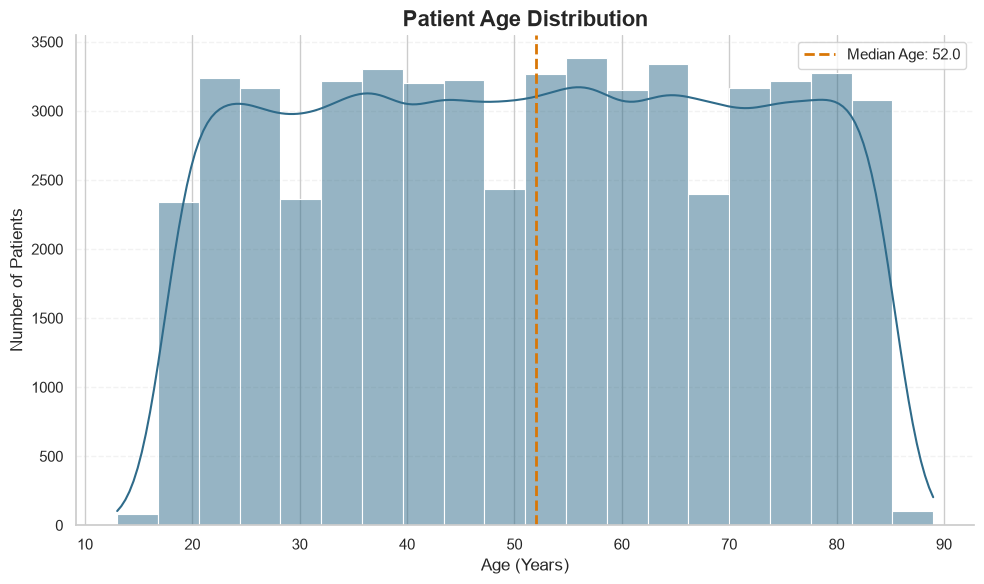

In [ ]:
#Note add this two libraries:(import matplotlib.pyplot as plt and import seaborn as sns )for the visualization.
#Data Visualization: First visualization: Age Distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True,
    color="#2F6B8A",
    edgecolor="white",
    linewidth=0.8
)

# Add median age reference line
median_age = df["age"].median()

plt.axvline(
    median_age,
    linestyle="--",
    linewidth=2,
    color="#D97706",
    label=f"Median Age: {median_age:.1f}"
)

plt.title(
    "Patient Age Distribution",
    fontsize=16,
    fontweight="bold",

)

plt.xlabel( "Age (Years)")
plt.ylabel("Number of Patients")


plt.legend()
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
#key statistics
print(f"Mean Age: {df['age'].mean():.1f} years")
print(f"Median Age: {df['age'].median():.1f} years")
print(f"Minimum Age: {df['age'].min()} years")
print(f"Maximum Age: {df['age'].max()} years")

Mean Age: 51.5 years
Median Age: 52.0 years
Minimum Age: 13 years
Maximum Age: 89 years


In [ ]:
#:Gender distribution
#create sum of gender_counts
gender_counts = (
    df["gender"]
    .value_counts()
    .reset_index()
)

gender_counts.columns = [
    "gender",
    "patient_count"
]

print(gender_counts)

   gender  patient_count
0    Male          27496
1  Female          27470


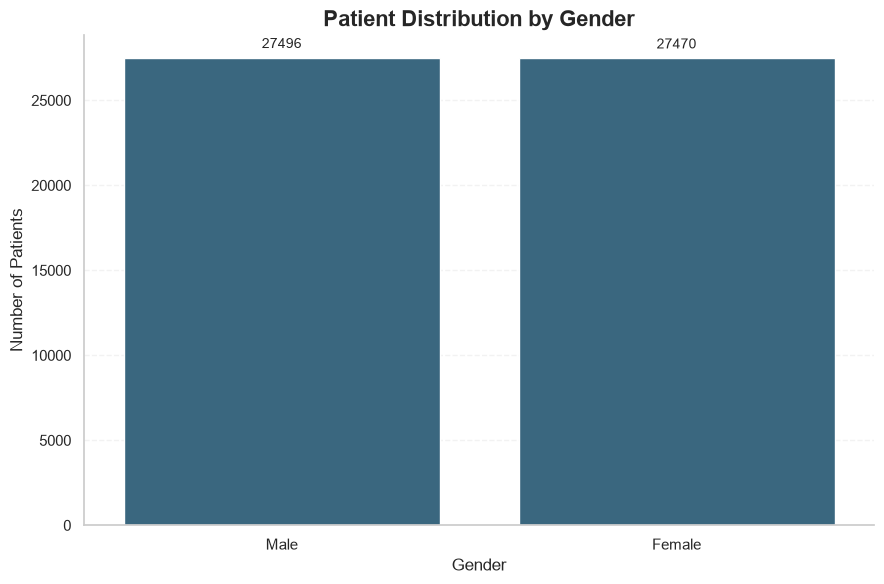

In [ ]:
#visualizing the number patient by gender
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=gender_counts,
    x="gender",
    y="patient_count",
    color="#2F6B8A"
)

# Add patient counts above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=5,
        fontsize=10
    )

plt.title(
    "Patient Distribution by Gender",
    fontsize=16,
    fontweight="bold",

)

plt.xlabel(
    "Gender",

)

plt.ylabel(
    "Number of Patients",

)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
#Medical conditions
#create condition count
condition_counts = (
    df["medical_condition"]
    .value_counts()
    .reset_index()
)

condition_counts.columns = [
    "medical_condition",
    "patient_count"
]
condition_counts = condition_counts.sort_values(
    "patient_count",
    ascending=True
)
print(condition_counts)


  medical_condition  patient_count
5            Asthma           9095
4            Cancer           9140
3           Obesity           9146
2      Hypertension           9151
1          Diabetes           9216
0         Arthritis           9218


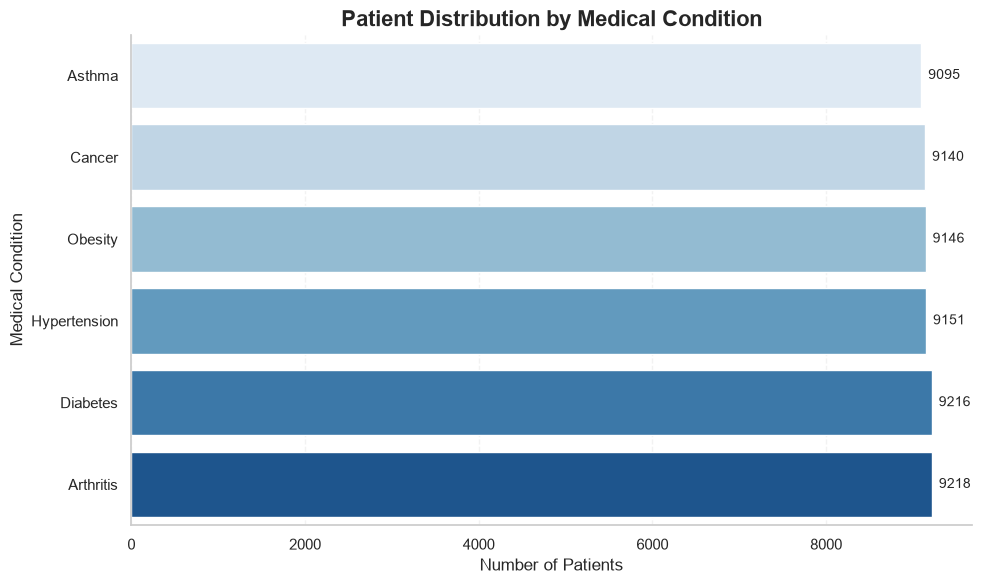

In [ ]:
#visualizing the medical condition
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=condition_counts,
    x="patient_count",
    y="medical_condition",
    hue="medical_condition",
    palette="Blues",
    legend=False
)

# Add patient counts to the bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=5,
        fontsize=10
    )

plt.title(
    "Patient Distribution by Medical Condition",
    fontsize=16,
    fontweight="bold"

)

plt.xlabel(
    "Number of Patients"

)

plt.ylabel(
    "Medical Condition"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
#Admission types
#create Admission count
admission_counts = (
    df["admission_type"]
    .value_counts()
    .reset_index()

)

admission_counts.columns = [
    "admission_type",
    "patient_count"
]
# Sort by patient count
admission_counts = admission_counts.sort_values(
    "patient_count",
    ascending=False
)
print(admission_counts)

  admission_type  patient_count
0       Elective          18473
1         Urgent          18391
2      Emergency          18102


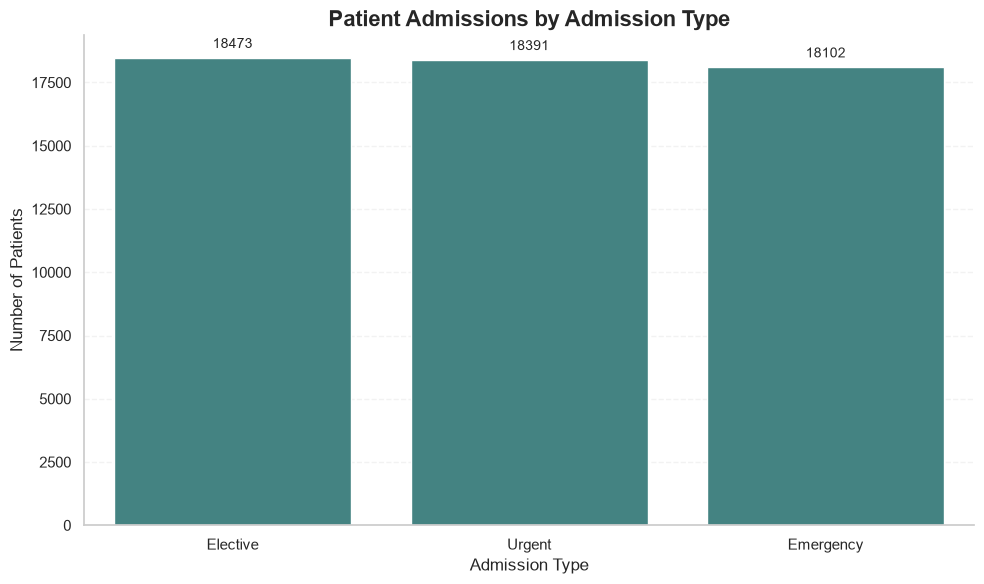

In [ ]:
#visualizing the Admission type
plt.figure(figsize=(10, 6))


ax = sns.barplot(
    data=admission_counts,
    x="admission_type",
    y="patient_count",
    color="#3A8D8C"
)

# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=5,
        fontsize=10
    )

plt.title(
    "Patient Admissions by Admission Type",
    fontsize=16,
    fontweight="bold"

)

plt.xlabel(
    "Admission Type"

)

plt.ylabel(
    "Number of Patients"

)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
#Financial analysis
#calculate billing by medical condition
billing_by_condition = (
    df.groupby("medical_condition")
      .agg(
          total_billing=("billing_amount", "sum"),
          average_billing=("billing_amount", "mean"),
          patient_count=("name", "nunique")
      )
      .sort_values(
          "total_billing",
          ascending=True # Sort from highest to lowest billing
      )
)
# adding the $ to the billing
billing_by_condition["total_billing"] = billing_by_condition["total_billing"].map(lambda x: f"${x:,.2f}")

billing_by_condition["average_billing"] = billing_by_condition["average_billing"].map(lambda x: f"${x:,.2f}")

print(billing_by_condition)


                     total_billing average_billing  patient_count
medical_condition                                                
Cancer             $229,892,231.73      $25,152.32           7853
Asthma             $233,136,334.13      $25,633.46           7837
Hypertension       $233,378,490.35      $25,503.06           7870
Arthritis          $235,167,617.96      $25,511.78           8019
Obesity            $236,006,693.95      $25,804.36           7844
Diabetes           $236,486,971.10      $25,660.48           7950


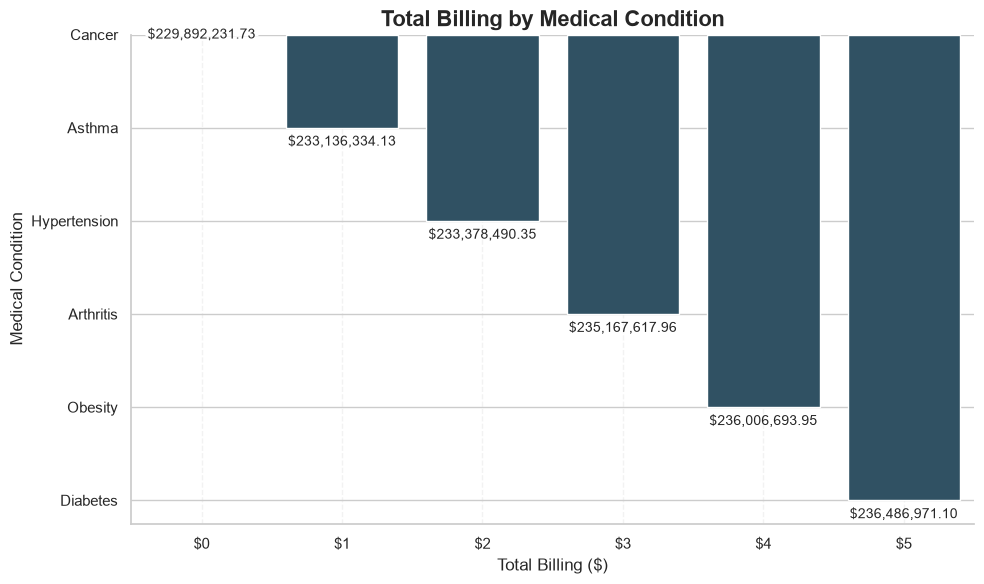

In [ ]:
#visualizing the Financial analysis
plt.figure(figsize=(10, 6))

# Sort from highest to lowest billing
billing_plot = (
    billing_by_condition
    .reset_index()
    .sort_values("total_billing", ascending=True)
)

ax = sns.barplot(
    data=billing_plot,
    x="total_billing",
    y="medical_condition",
    color="#28536B"
)
# to avoid errors in the figures converting to numeric
billing_plot["total_billing"] = (
    billing_plot["total_billing"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

billing_plot["total_billing"] = pd.to_numeric(
    billing_plot["total_billing"],
    errors="coerce"
)


# Add dollar values to the bars
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"${value:,.2f}"
            for value in billing_plot["total_billing"]


        ],
        padding=5,
        fontsize=10
    )

plt.title(
    "Total Billing by Medical Condition",
    fontsize=16,
    fontweight="bold",

)

plt.xlabel(
    "Total Billing ($)"

)

plt.ylabel(
    "Medical Condition"

)

# Currency formatting on x-axis
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
#Hospital analysis
#creating analytical table
hospital_analysis = (
    df.groupby("hospital")
      .agg(
          patient_count=("name", "nunique"),
          total_billing=("billing_amount", "sum"),
          average_billing=("billing_amount", "mean"),
          average_length_of_stay=("length_of_stay", "mean")
      )
      .sort_values(
          "patient_count",
          ascending=False
      )
)

print(hospital_analysis.head(10))


             patient_count  total_billing  average_billing  \
hospital                                                     
LLC Smith               40   1.030190e+06     23413.406187   
Johnson PLC             35   1.081477e+06     29229.116540   
Ltd Smith               35   1.003366e+06     25727.321223   
Smith Ltd               35   9.700359e+05     26217.185560   
Smith PLC               33   1.029424e+06     28595.123587   
Smith Group             32   8.066313e+05     22406.424743   
Group Smith             30   9.029758e+05     28217.993358   
Johnson Inc             29   9.343107e+05     27479.727296   
Smith Inc               29   7.722565e+05     23401.711987   
Smith LLC               28   7.316836e+05     22865.113939   

             average_length_of_stay  
hospital                             
LLC Smith                 15.568182  
Johnson PLC               16.135135  
Ltd Smith                 16.512821  
Smith Ltd                 15.135135  
Smith PLC                 1

In [ ]:
#Length of stay analysis
#calculate average stay by condition:
stay_by_condition = (
    df.groupby("medical_condition")
      .agg(
          average_length_of_stay=(
              "length_of_stay",
              "mean"
          ),
          patient_count=("name", "nunique")
      )
      .sort_values(
          "average_length_of_stay",
          ascending=True
      )
)

print(stay_by_condition)

                   average_length_of_stay  patient_count
medical_condition                                       
Diabetes                        15.430664           7950
Hypertension                    15.436236           7870
Obesity                         15.447627           7844
Cancer                          15.501204           7853
Arthritis                       15.504231           8019
Asthma                          15.677295           7837


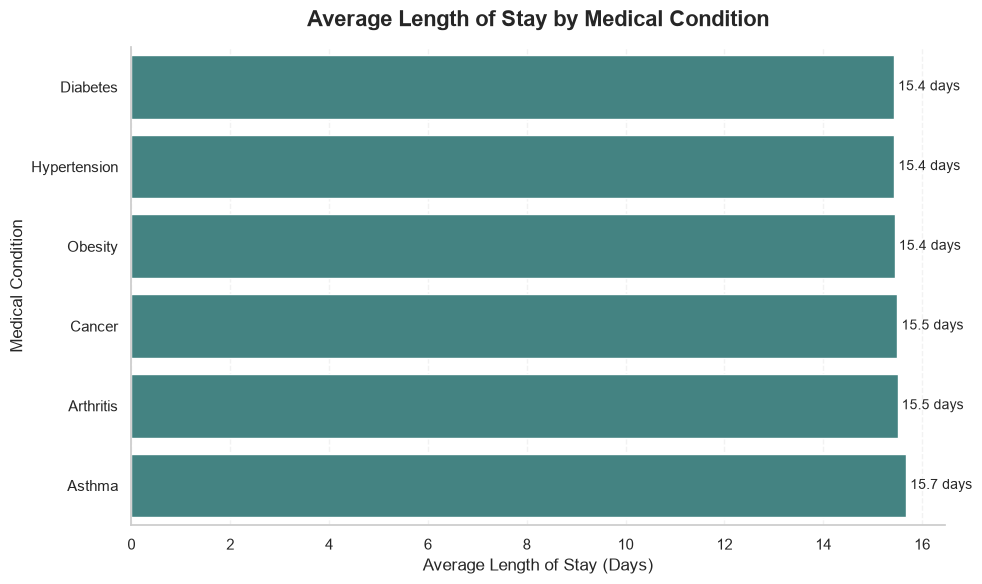

In [ ]:
#visualizing stay by condition
stay_plot = (
    stay_by_condition
    .reset_index()
    .sort_values(
        "average_length_of_stay",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=stay_plot,
    x="average_length_of_stay",
    y="medical_condition",
    color="#3A8D8C"
)

# Add values to the bars
for i, value in enumerate(stay_plot["average_length_of_stay"]):
    ax.text(
        value,
        i,
        f" {value:.1f} days",
        va="center",
        fontsize=10
    )

plt.title(
    "Average Length of Stay by Medical Condition",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Average Length of Stay (Days)"

)

plt.ylabel(
    "Medical Condition"

)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
#Admission trends
monthly_admissions = (
    df.groupby(
        df["date_of_admission"].dt.to_period("M")
    )
    .size()
    .reset_index(name="patient_count")
)
#convert the period
monthly_admissions = (
    df.groupby(
        df["date_of_admission"].dt.to_period("M")
    )
    .size()
    .reset_index(name="patient_count")
)
monthly_admissions["date_of_admission"] = (
    monthly_admissions["date_of_admission"].dt.to_timestamp()
)
print(monthly_admissions)

   date_of_admission  patient_count
0         2019-05-01            677
1         2019-06-01            899
2         2019-07-01            951
3         2019-08-01            985
4         2019-09-01            924
..               ...            ...
56        2024-01-01            903
57        2024-02-01            869
58        2024-03-01            902
59        2024-04-01            941
60        2024-05-01            212

[61 rows x 2 columns]


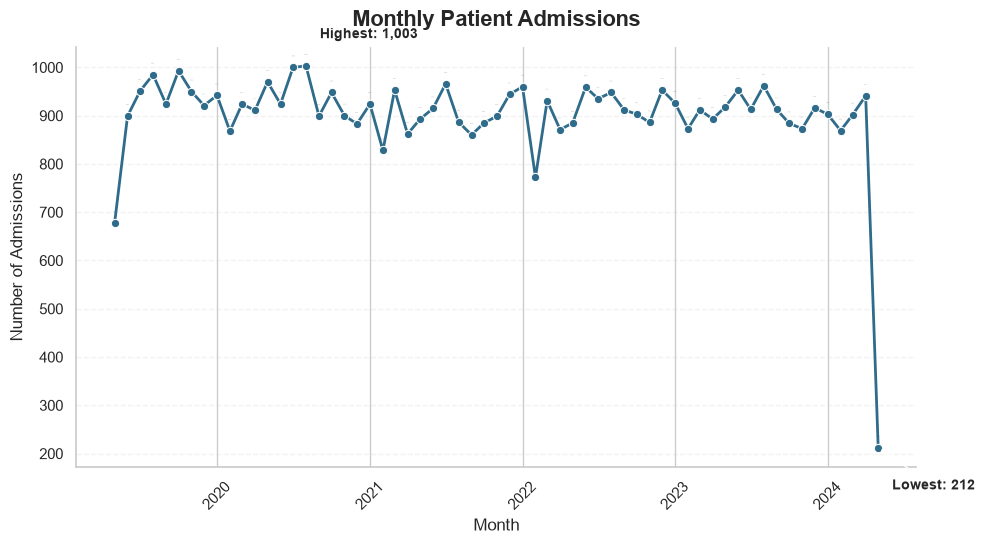

In [ ]:
#visualizing monthly_admissions to identify the trend over time
plt.figure(figsize=(12, 6), dpi=100)

ax = sns.lineplot(
    data=monthly_admissions,
    x="date_of_admission",
    y="patient_count",
    color="#2F6B8A",
    marker="o",
    linewidth=2
)

# Add patient counts to each point
for x, y in zip(
    monthly_admissions["date_of_admission"],
    monthly_admissions["patient_count"]
):
    ax.annotate(
        f"{y:,}",
        (x, y),

        xytext=(0, 8),
        textcoords="offset points", # Added this to match your other annotations
        ha="center",
        fontsize=0
    )

# Identify highest and lowest admission months
max_row = monthly_admissions.loc[
    monthly_admissions["patient_count"].idxmax()
]

min_row = monthly_admissions.loc[
    monthly_admissions["patient_count"].idxmin()
]

# Highlight maximum
ax.annotate(
    f"Highest: {max_row['patient_count']:,}",
    xy=(
        max_row["date_of_admission"],
        max_row["patient_count"]
    ),
    xytext=(10, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->"),
    fontsize=10,
    fontweight="bold"
)

# Highlight minimum
ax.annotate(
    f"Lowest: {min_row['patient_count']:,}",
    xy=(
        min_row["date_of_admission"],
        min_row["patient_count"]
    ),
    xytext=(10, -30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->"),
    fontsize=10,
    fontweight="bold"
)

plt.title(
    "Monthly Patient Admissions",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Month"

)

plt.ylabel(
    "Number of Admissions"

)

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.subplots_adjust(
    left=0.20,
    right=0.90,
    bottom=0.20,
    top=0.90
)

plt.show()

In [ ]:
#correlation analysis
# selecting numerical columns
numeric_columns = [
    "age",
    "billing_amount",
    "room_number",
    "length_of_stay"
]

correlation_matrix = df[numeric_columns].corr()
print(correlation_matrix)

                     age  billing_amount  room_number  length_of_stay
age             1.000000       -0.003427    -0.000352        0.007890
billing_amount -0.003427        1.000000    -0.003930       -0.004891
room_number    -0.000352       -0.003930     1.000000       -0.004540
length_of_stay  0.007890       -0.004891    -0.004540        1.000000


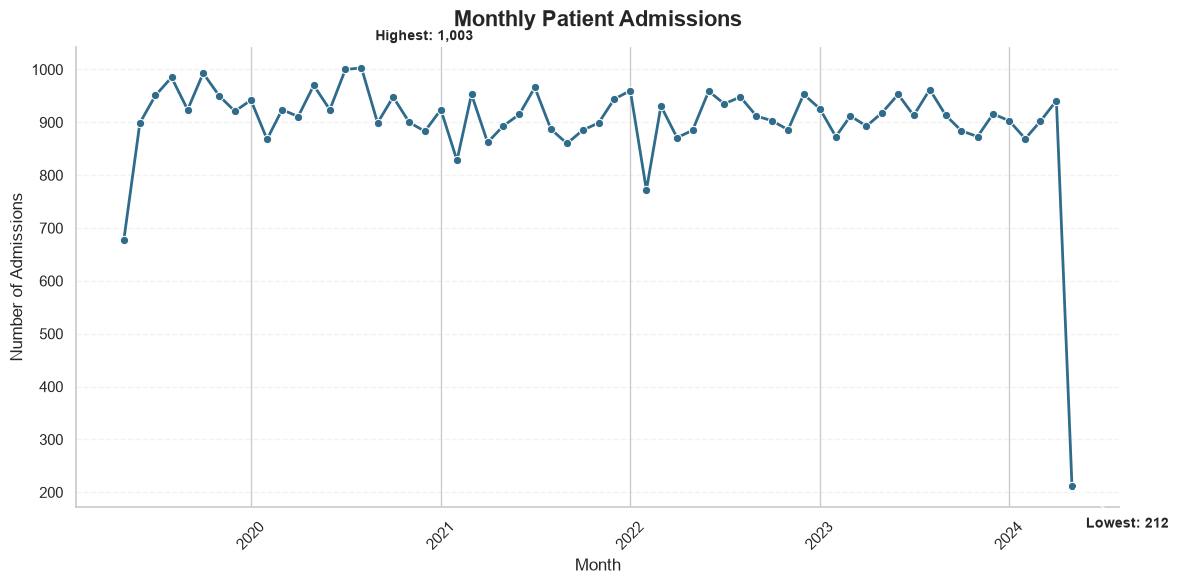

In [ ]:
plt.figure(figsize=(12, 6), dpi=100)

ax = sns.lineplot(
    data=monthly_admissions,
    x="date_of_admission",
    y="patient_count",
    color="#2F6B8A",
    marker="o",
    linewidth=2
)

# --- RE-ADDED FOR REFERENCE: The point-labeling loop has been removed ---

# Identify highest and lowest admission months
max_row = monthly_admissions.loc[monthly_admissions["patient_count"].idxmax()]
min_row = monthly_admissions.loc[monthly_admissions["patient_count"].idxmin()]

# Highlight maximum
ax.annotate(
    f"Highest: {max_row['patient_count']:,}",
    xy=(max_row["date_of_admission"], max_row["patient_count"]),
    xytext=(10, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->"),
    fontsize=10,
    fontweight="bold"
)

# Highlight minimum
ax.annotate(
    f"Lowest: {min_row['patient_count']:,}",
    xy=(min_row["date_of_admission"], min_row["patient_count"]),
    xytext=(10, -30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->"),
    fontsize=10,
    fontweight="bold"
)

plt.title("Monthly Patient Admissions", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.25)
sns.despine()

plt.tight_layout()
plt.show()


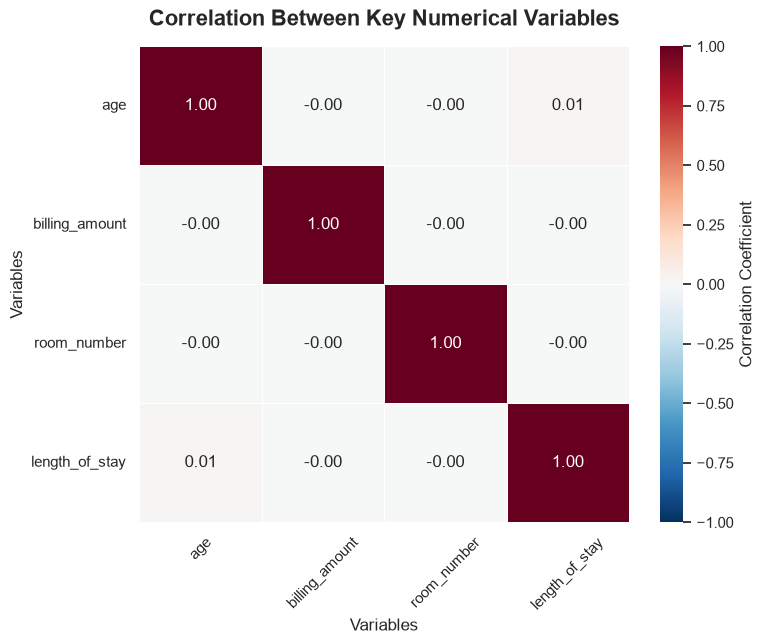

In [ ]:
#visualizing the correlation
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Correlation Coefficient"
    },
    ax=ax
)

ax.set_title(
    "Correlation Between Key Numerical Variables",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Variables")
ax.set_ylabel("Variables")

ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

fig.subplots_adjust(
    left=0.20,
    right=0.88,
    bottom=0.20,
    top=0.88
)

plt.show()